## 1. Cài thư viện

In [1]:
!pip install datasets underthesea optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 50.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.5 MB/s eta 0:00:00:00:01


## 2. Import & cấu hình chung

In [2]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
)
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
tqdm.pandas()

LABEL_NAMES = ['NON-HATE', 'HATE']
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports done.")


Imports done.


## 3. Load Dataset từ Hugging Face

In [3]:
from kaggle_secrets import UserSecretsClient
from datasets import load_dataset
import huggingface_hub

secret_label = "HF_TOKEN"
secret_value = UserSecretsClient().get_secret(secret_label)
huggingface_hub.login(token=secret_value, add_to_git_credential=False)

ds = load_dataset("sonlam1102/vihsd")
train_df = ds["train"].to_pandas()
dev_df   = ds["validation"].to_pandas()
test_df  = ds["test"].to_pandas()

print(f"Train: {len(train_df):,} | Dev: {len(dev_df):,} | Test: {len(test_df):,}")
print(f"Columns: {train_df.columns.tolist()}")


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

dev.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Train: 24,048 | Dev: 2,672 | Test: 6,680
Columns: ['free_text', 'label_id']


## 4. Label Mapping

In [4]:
# CLEAN=0, OFFENSIVE=1 -> NON-HATE=0 | HATE=2 -> HATE=1
def map_label(x):
    return 1 if x == 2 else 0

for df in [train_df, dev_df, test_df]:
    df['label_id'] = df['label_id'].map(map_label)

label_map = {0: 'NON-HATE', 1: 'HATE'}

print("Label distribution sau mapping (train):")
print(train_df['label_id'].value_counts().sort_index().rename(label_map))
print()
print("Label distribution sau mapping (dev):")
print(dev_df['label_id'].value_counts().sort_index().rename(label_map))
print()
print("Label distribution sau mapping (test):")
print(test_df['label_id'].value_counts().sort_index().rename(label_map))
train_df.head(3)


Label distribution sau mapping (train):
label_id
NON-HATE    21492
HATE         2556
Name: count, dtype: int64

Label distribution sau mapping (dev):
label_id
NON-HATE    2402
HATE         270
Name: count, dtype: int64

Label distribution sau mapping (test):
label_id
NON-HATE    5992
HATE         688
Name: count, dtype: int64


,free_text,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,1
2,Đậu Văn Cường giờ giống thằng sida hơn à,0


## 5. Tiền xử lý văn bản

In [5]:
from underthesea import word_tokenize

TEENCODE_MAP = {
    'ko': 'không', 'kh': 'không', 'khong': 'không', 'kg': 'không',
    'hok': 'không', 'hk': 'không', 'hem': 'không', 'kô': 'không',
    'chx': 'chưa', 'chua': 'chưa',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'oy': 'rồi', 'uj': 'rồi',
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình',
    'tui': 'tôi', 'tau': 'tao',
    'may': 'mày', 'mi': 'mày',
    'bn': 'bạn', 'ban': 'bạn',
    'no': 'nó', 'mng': 'mọi người', 'mn': 'mọi người', 'ae': 'anh em',
    'dc': 'được', 'đc': 'được', 'dk': 'được', 'đk': 'được',
    'đươc': 'được', 'duoc': 'được',
    'vs': 'với', 'voi': 'với',
    'j': 'gì', 'zì': 'gì', 'zi': 'gì',
    'ntn': 'như thế nào', 'nso': 'như sao',
    'biet': 'biết', 'bit': 'biết', 'hieu': 'hiểu', 'nghi': 'nghĩ',
    'muon': 'muốn', 'hoac': 'hoặc', 'neu': 'nếu', 'nen': 'nên',
    'giet': 'giết', 'chui': 'chửi', 'danh': 'đánh',
    'nx': 'nhưng', 'nhg': 'nhưng', 'nhưg': 'nhưng', 'nma': 'nhưng mà',
    'cx': 'cũng', 'cg': 'cũng', 'cung': 'cũng', 'cũg': 'cũng',
    'ms': 'mới', 'boi': 'bởi',
    'oke': 'ok', 'okie': 'ok', 'okê': 'ok', 'okey': 'ok',
    'uh': 'ừ', 'uk': 'ừ', 'uhm': 'ừ',
    'yep': 'đúng', 'yup': 'đúng',
    'haha': 'haha', 'hehe': 'hehe', 'hihi': 'hehe', 'huhu': 'buồn',
    'haiz': 'thở dài', 'haizz': 'thở dài',
    'wtf': 'cái gì vậy', 'omg': 'ôi trời',
    'lol': 'buồn cười', 'lmao': 'buồn cười',
    'fck': 'chửi thề', 'fk': 'chửi thề', 'gg': 'xong rồi', 'ez': 'dễ',
    'bt': 'bình thường', 'bth': 'bình thường',
    'noob': 'tệ', 'nub': 'tệ',
    'xàm': 'vô nghĩa', 'nhảm': 'vô nghĩa',
    'pro': 'giỏi',
    'vl': 'vãi lồn', 'vcl': 'vãi cái lồn', 'vkl': 'vãi kép lồn',
    'vll': 'vãi lồn', 'vleu': 'vãi lồn', 'vloz': 'vãi lồn',
    'dm': 'đụ má', 'đm': 'đụ má', 'd.m': 'đụ má', 'đ.m': 'đụ má',
    'đmm': 'đụ má mày', 'dmm': 'đụ má mày',
    'đtm': 'địt mẹ', 'dtm': 'địt mẹ',
    'cl': 'cái lồn', 'lon': 'lồn', 'loz': 'lồn', 'l0n': 'lồn',
    'đéo': 'không', 'deo': 'không', 'éo': 'không',
    'cc': 'cái con', 'thg': 'thằng',
    'ngu': 'ngu', 'đần': 'đần độn', 'khùng': 'điên', 'dien': 'điên',
    'cút': 'cút', 'cut': 'cút',
    'câm': 'câm miệng', 'im mồm': 'câm miệng',
    'fb': 'facebook', 'yt': 'youtube', 'tt': 'tiktok', 'zl': 'zalo',
    'ig': 'instagram', 'cmt': 'bình luận', 'rep': 'trả lời',
    'vn': 'việt nam', 'hn': 'hà nội', 'hcm': 'hồ chí minh', 'sg': 'sài gòn',
    'iu': 'yêu', 'ieu': 'yêu',
}


def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b0[0-9]{9,10}\b', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [TEENCODE_MAP.get(w, w) for w in words]
    return ' '.join(words)


def preprocess(text: str, use_word_segment: bool = True) -> str:
    text = normalize_text(text)
    if use_word_segment and text:
        try:
            text = word_tokenize(text, format='text')
        except Exception:
            pass
    return text


sample = 'mày ko hiểu gì hết, ngu vcl!!'
print(f'Original : {sample}')
print(f'Processed: {preprocess(sample)}')


Original : mày ko hiểu gì hết, ngu vcl!!
Processed: mày không hiểu gì hết ngu_vãi cái lồn


## 6. Áp dụng tiền xử lý

In [6]:
print("Preprocessing texts...")

for df, name in [(train_df, 'Train'), (dev_df, 'Dev'), (test_df, 'Test')]:
    df['text_processed'] = df['free_text'].progress_apply(preprocess)
    print(f'  {name}: done')

print()
print("Sample:")
for _, row in train_df.sample(3, random_state=42).iterrows():
    lbl = label_map[row['label_id']]
    print(f'  [{lbl:>8}] {row["free_text"][:55]} -> {row["text_processed"][:55]}')


Preprocessing texts...


  0%|          | 0/24048 [00:00<?, ?it/s]

  Train: done


  0%|          | 0/2672 [00:00<?, ?it/s]

  Dev: done


  0%|          | 0/6680 [00:00<?, ?it/s]

  Test: done

Sample:
  [NON-HATE] Ko biết là 10.000 công nhân hay 10.000 lính @.@ -> không biết là 10 00 công_nhân hay 10 00 lính
  [NON-HATE] Thằng -> thằng
  [NON-HATE] Người ieu cua ai bắt về dùm đi cảm ơn ...cho nó hút khí -> người yêu cua ai bắt về dùm đi cảm_ơn cho nó hút khí bo


## 7. TF-IDF Vectorization

In [7]:
X_train_text = train_df['text_processed'].fillna('').tolist()
X_dev_text   = dev_df['text_processed'].fillna('').tolist()
X_test_text  = test_df['text_processed'].fillna('').tolist()

y_train = train_df['label_id'].values
y_dev   = dev_df['label_id'].values
y_test  = test_df['label_id'].values

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b',
)

X_train = tfidf.fit_transform(X_train_text)
X_dev   = tfidf.transform(X_dev_text)
X_test  = tfidf.transform(X_test_text)

print(f'Vocab size: {len(tfidf.vocabulary_):,}')
print(f'X_train: {X_train.shape}  X_dev: {X_dev.shape}  X_test: {X_test.shape}')


Vocab size: 34,691
X_train: (24048, 34691)  X_dev: (2672, 34691)  X_test: (6680, 34691)


## 8. Evaluation Helpers

In [8]:
results_table = []


def evaluate_model(name, model, X_eval, y_eval, split_name='Dev'):
    y_pred = model.predict(X_eval)

    acc         = accuracy_score(y_eval, y_pred)
    f1_macro    = f1_score(y_eval, y_pred, average='macro')
    f1_weighted = f1_score(y_eval, y_pred, average='weighted')
    f1_cls      = f1_score(y_eval, y_pred, average=None)

    print(f'\n{name} — {split_name}')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  F1 Macro   : {f1_macro:.4f}')
    print(f'  F1 Weighted: {f1_weighted:.4f}')
    for i, lbl in enumerate(LABEL_NAMES):
        print(f'  F1 {lbl:>10}: {f1_cls[i]:.4f}')
    print()
    print(classification_report(y_eval, y_pred, target_names=LABEL_NAMES))

    res = {
        'Model': name, 'Split': split_name,
        'Accuracy': round(acc, 4),
        'F1 Macro': round(f1_macro, 4),
        'F1 Weighted': round(f1_weighted, 4),
        **{f'F1 {LABEL_NAMES[i]}': round(f1_cls[i], 4) for i in range(len(LABEL_NAMES))},
    }
    results_table.append(res)
    return res


def train_and_evaluate(name, model, X_tr, y_tr, X_d, y_d, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    print(f'{name} trained in {time.time() - t0:.1f}s')
    evaluate_model(name, model, X_d, y_d, 'Dev')
    evaluate_model(name, model, X_te, y_te, 'Test')
    return model


## 9. Model 1 — TF-IDF + Logistic Regression

Tuning `C` bằng Optuna trên Dev set (F1 Macro).

In [9]:
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    model = LogisticRegression(
        C=C, max_iter=1000, class_weight='balanced',
        solver='lbfgs', random_state=RANDOM_STATE, n_jobs=-1,
    )
    model.fit(X_train, y_train)
    return f1_score(y_dev, model.predict(X_dev), average='macro')


study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=20, show_progress_bar=True)

best_C = study_lr.best_params['C']
print(f'Best C = {best_C:.4f}  |  F1 Macro (Dev) = {study_lr.best_value:.4f}')

lr_model = LogisticRegression(
    C=best_C, max_iter=1000, class_weight='balanced',
    solver='lbfgs', random_state=RANDOM_STATE, n_jobs=-1,
)
lr_model = train_and_evaluate(
    'TF-IDF + LR (Tuned)', lr_model,
    X_train, y_train, X_dev, y_dev, X_test, y_test,
)


  0%|          | 0/20 [00:00<?, ?it/s]

Best C = 8.9560  |  F1 Macro (Dev) = 0.7522
TF-IDF + LR (Tuned) trained in 1.4s

TF-IDF + LR (Tuned) — Dev
  Accuracy   : 0.8930
  F1 Macro   : 0.7522
  F1 Weighted: 0.9012
  F1   NON-HATE: 0.9390
  F1       HATE: 0.5653

              precision    recall  f1-score   support

    NON-HATE       0.96      0.92      0.94      2402
        HATE       0.48      0.69      0.57       270

    accuracy                           0.89      2672
   macro avg       0.72      0.80      0.75      2672
weighted avg       0.91      0.89      0.90      2672


TF-IDF + LR (Tuned) — Test
  Accuracy   : 0.8910
  F1 Macro   : 0.7393
  F1 Weighted: 0.8972
  F1   NON-HATE: 0.9382
  F1       HATE: 0.5404

              precision    recall  f1-score   support

    NON-HATE       0.96      0.92      0.94      5992
        HATE       0.48      0.62      0.54       688

    accuracy                           0.89      6680
   macro avg       0.72      0.77      0.74      6680
weighted avg       0.91      0.89   

## 10. Model 2 — TF-IDF + SVM

Tuning `C` cho LinearSVC.

In [10]:
def objective_svm(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    base = LinearSVC(C=C, class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE)
    model = CalibratedClassifierCV(base, cv=3)
    model.fit(X_train, y_train)
    return f1_score(y_dev, model.predict(X_dev), average='macro')


study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=15, show_progress_bar=True)

best_C_svm = study_svm.best_params['C']
print(f'Best C = {best_C_svm:.4f}  |  F1 Macro (Dev) = {study_svm.best_value:.4f}')

svm_base = LinearSVC(
    C=best_C_svm, class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE,
)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model = train_and_evaluate(
    'TF-IDF + SVM (Tuned)', svm_model,
    X_train, y_train, X_dev, y_dev, X_test, y_test,
)


  0%|          | 0/15 [00:00<?, ?it/s]

Best C = 0.1105  |  F1 Macro (Dev) = 0.7465
TF-IDF + SVM (Tuned) trained in 0.3s

TF-IDF + SVM (Tuned) — Dev
  Accuracy   : 0.9199
  F1 Macro   : 0.7465
  F1 Weighted: 0.9138
  F1   NON-HATE: 0.9562
  F1       HATE: 0.5368

              precision    recall  f1-score   support

    NON-HATE       0.94      0.97      0.96      2402
        HATE       0.65      0.46      0.54       270

    accuracy                           0.92      2672
   macro avg       0.79      0.72      0.75      2672
weighted avg       0.91      0.92      0.91      2672


TF-IDF + SVM (Tuned) — Test
  Accuracy   : 0.9126
  F1 Macro   : 0.7131
  F1 Weighted: 0.9030
  F1   NON-HATE: 0.9523
  F1       HATE: 0.4739

              precision    recall  f1-score   support

    NON-HATE       0.93      0.97      0.95      5992
        HATE       0.62      0.38      0.47       688

    accuracy                           0.91      6680
   macro avg       0.78      0.68      0.71      6680
weighted avg       0.90      0.91

## 11. Confusion Matrix

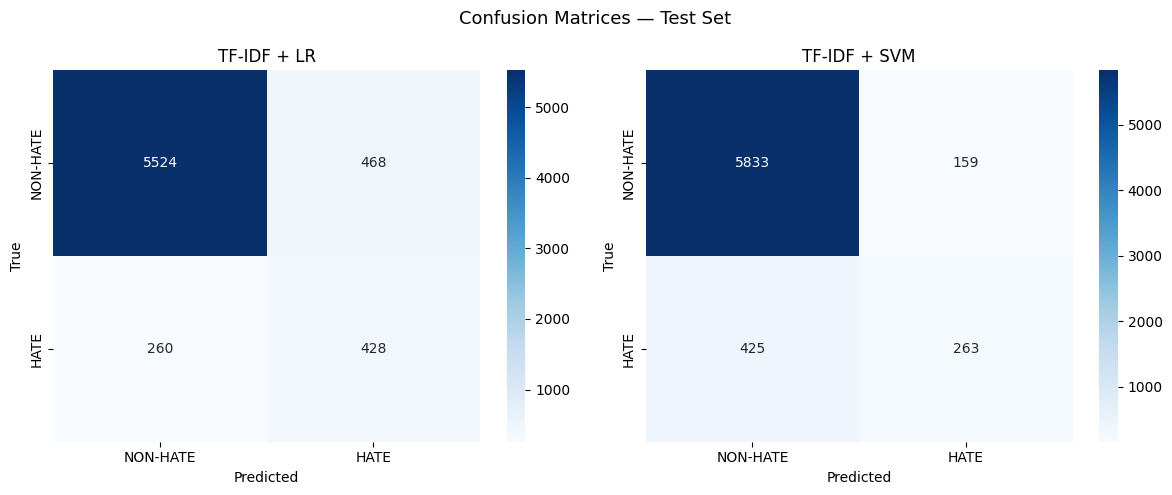

In [11]:
models_dict = {
    'TF-IDF + LR':  lr_model,
    'TF-IDF + SVM': svm_model,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, models_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax,
    )
    ax.set_title(name)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Kết quả tổng hợp

In [12]:
results_df = pd.DataFrame(results_table)

test_results = (
    results_df[results_df['Split'] == 'Test']
    .drop('Split', axis=1)
    .sort_values('F1 Macro', ascending=False)
    .reset_index(drop=True)
)

print("Test Set Results — ViHSD Baseline ML (binary: NON-HATE / HATE)")
print(test_results.to_string(index=False))

best = test_results.iloc[0]
print(f'\nBest model: {best["Model"]}  (F1 Macro = {best["F1 Macro"]})')


Test Set Results — ViHSD Baseline ML (binary: NON-HATE / HATE)
               Model  Accuracy  F1 Macro  F1 Weighted  F1 NON-HATE  F1 HATE
 TF-IDF + LR (Tuned)    0.8910    0.7393       0.8972       0.9382   0.5404
TF-IDF + SVM (Tuned)    0.9126    0.7131       0.9030       0.9523   0.4739

Best model: TF-IDF + LR (Tuned)  (F1 Macro = 0.7393)


## 13. Visualization

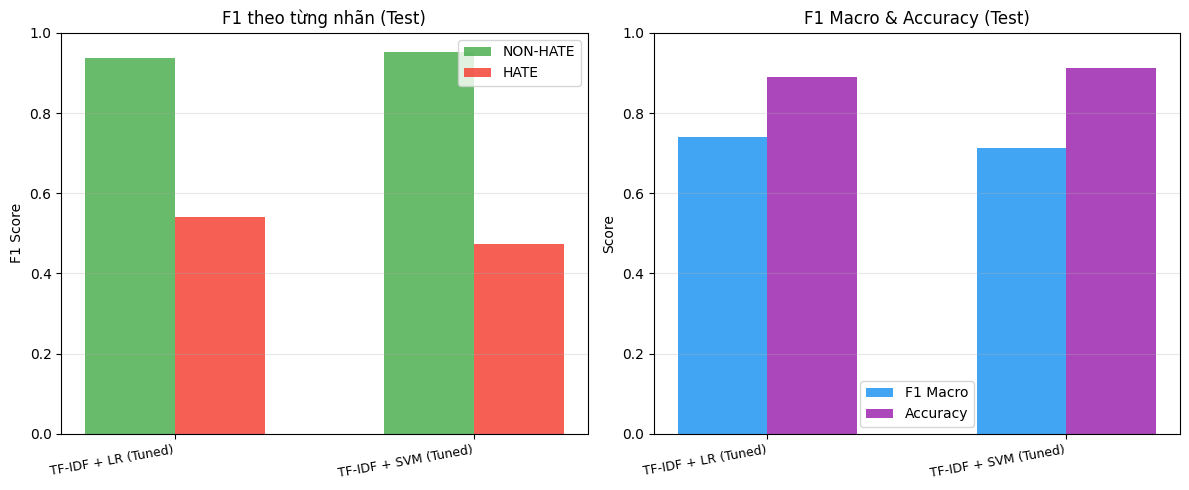

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models_list = test_results['Model'].tolist()
x = np.arange(len(models_list))
w = 0.3

ax = axes[0]
ax.bar(x - w/2, test_results['F1 NON-HATE'], w, label='NON-HATE', color='#4CAF50', alpha=0.85)
ax.bar(x + w/2, test_results['F1 HATE'],     w, label='HATE',     color='#F44336', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=10, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('F1 theo từng nhãn (Test)')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.bar(x - w/2, test_results['F1 Macro'], w, label='F1 Macro', color='#2196F3', alpha=0.85)
ax2.bar(x + w/2, test_results['Accuracy'], w, label='Accuracy', color='#9C27B0', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=10, ha='right', fontsize=9)
ax2.set_ylabel('Score')
ax2.set_title('F1 Macro & Accuracy (Test)')
ax2.legend()
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Lưu models & kết quả

In [14]:
import joblib, os

os.makedirs('models', exist_ok=True)

joblib.dump(tfidf,     'models/tfidf_vectorizer.pkl')
joblib.dump(lr_model,  'models/lr_model.pkl')
joblib.dump(svm_model, 'models/svm_model.pkl')

results_df.to_csv('baseline_ml_results.csv', index=False)

print("Saved:")
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f}  ({size:.0f} KB)')
print("  baseline_ml_results.csv")
print("  baseline_ml_results.png")
print("  confusion_matrices.png")


Saved:
  models/lr_model.pkl  (272 KB)
  models/svm_model.pkl  (815 KB)
  models/tfidf_vectorizer.pkl  (1356 KB)
  baseline_ml_results.csv
  baseline_ml_results.png
  confusion_matrices.png


## 15. Optuna Tuning Summary

In [15]:
print("Optuna Best Trials")
print()
for name, study in [('LR', study_lr), ('SVM', study_svm)]:
    print(f'{name}: F1 Macro = {study.best_value:.4f}')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
    print()

print("Dev vs Test")
pivot = results_df.pivot_table(
    index='Model', columns='Split',
    values=['Accuracy', 'F1 Macro', 'F1 HATE'],
    aggfunc='first',
)
print(pivot.to_string())


Optuna Best Trials

LR: F1 Macro = 0.7522
  C: 8.955993422862592

SVM: F1 Macro = 0.7465
  C: 0.11048411217275321

Dev vs Test
                     Accuracy         F1 HATE         F1 Macro        
Split                     Dev    Test     Dev    Test      Dev    Test
Model                                                                 
TF-IDF + LR (Tuned)    0.8930  0.8910  0.5653  0.5404   0.7522  0.7393
TF-IDF + SVM (Tuned)   0.9199  0.9126  0.5368  0.4739   0.7465  0.7131


## 16. Kiểm chứng nhanh

In [16]:
def predict_text(text, model, tfidf_vectorizer, label_names):
    cleaned = preprocess(text)
    X_one = tfidf_vectorizer.transform([cleaned])
    pred_idx = int(model.predict(X_one)[0])
    pred_label = label_names[pred_idx]
    scores = None
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_one)[0]
        scores = {label_names[i]: float(probs[i]) for i in range(len(label_names))}
    return {'raw': text, 'processed': cleaned, 'label': pred_label, 'scores': scores}


TEST_CASES = [
    ("Hôm nay trời đẹp quá, đi chơi thôi!",                  "NON-HATE"),
    ("Tụi nó toàn nói nhảm, đúng là quá toxic",               "NON-HATE"),
    ("Đồ ngu, câm miệng lại đi mày",                          "NON-HATE"),
    ("Tao ghét cái loại người như mày, xéo đi cho khuất mắt", "HATE"),
    ("Cảm ơn bạn đã giúp đỡ mình nhé!",                       "NON-HATE"),
    ("Tao cảm ơn mày nhiều lắm",                              "NON-HATE"),
]

models_dict = {
    'TF-IDF + LR':  lr_model,
    'TF-IDF + SVM': svm_model,
}

correct_counts = {name: 0 for name in models_dict}

for text, expected in TEST_CASES:
    print(f'Input   : {text}')
    print(f'Expected: {expected}')
    for name, mdl in models_dict.items():
        out = predict_text(text, mdl, tfidf, LABEL_NAMES)
        match = 'OK' if out['label'] == expected else 'WRONG'
        if out['label'] == expected:
            correct_counts[name] += 1
        prob_str = ' | '.join([f'{k}: {v:.2f}' for k, v in out['scores'].items()]) if out['scores'] else 'N/A'
        print(f'  {name:<20} {out["label"]:<10} {match:<6} {prob_str}')
    print()

print("Summary:")
for name, correct in correct_counts.items():
    print(f'  {name:<20} {correct}/{len(TEST_CASES)}  ({correct/len(TEST_CASES)*100:.0f}%)')


Input   : Hôm nay trời đẹp quá, đi chơi thôi!
Expected: NON-HATE
  TF-IDF + LR          NON-HATE   OK     NON-HATE: 0.99 | HATE: 0.01
  TF-IDF + SVM         NON-HATE   OK     NON-HATE: 0.99 | HATE: 0.01

Input   : Tụi nó toàn nói nhảm, đúng là quá toxic
Expected: NON-HATE
  TF-IDF + LR          HATE       WRONG  NON-HATE: 0.21 | HATE: 0.79
  TF-IDF + SVM         HATE       WRONG  NON-HATE: 0.31 | HATE: 0.69

Input   : Đồ ngu, câm miệng lại đi mày
Expected: NON-HATE
  TF-IDF + LR          HATE       WRONG  NON-HATE: 0.00 | HATE: 1.00
  TF-IDF + SVM         HATE       WRONG  NON-HATE: 0.02 | HATE: 0.98

Input   : Tao ghét cái loại người như mày, xéo đi cho khuất mắt
Expected: HATE
  TF-IDF + LR          HATE       OK     NON-HATE: 0.25 | HATE: 0.75
  TF-IDF + SVM         HATE       OK     NON-HATE: 0.37 | HATE: 0.63

Input   : Cảm ơn bạn đã giúp đỡ mình nhé!
Expected: NON-HATE
  TF-IDF + LR          NON-HATE   OK     NON-HATE: 0.99 | HATE: 0.01
  TF-IDF + SVM         NON-HATE   OK     NO